# Fasting on the Pitch
## DSA210 – Spring 2025-2026

## 1. Data Collection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('muslim_player_matches.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Total observations: {len(df)}")
print(f"Ramadan observations: {df['is_ramadan'].sum()}")
print(f"Non-Ramadan observations: {(~df['is_ramadan']).sum()}")
print(f"Unique players: {df['clean_name'].nunique()}")
print(f"Leagues: {df['league'].unique()}")
print(f"Seasons: {df['season'].unique()}")

Total observations: 32429
Ramadan observations: 3032
Non-Ramadan observations: 29397
Unique players: 784
Leagues: <StringArray>
['ENG-Premier League',        'ESP-La Liga',     'GER-Bundesliga',
        'ITA-Serie A',        'FRA-Ligue 1']
Length: 5, dtype: str
Seasons: [2021 2022 2023 2024]


## 2. Data Cleaning & Integration

In [4]:
import pandas as pd

#Final Dataset Loading
df = pd.read_csv('muslim_player_matches.csv')
df['date'] = pd.to_datetime(df['date'])

#Analyzing the Dataset
print(f"Total match observations: {len(df)}")
print(f"Unique Muslim players: {df['clean_name'].nunique()}")
print(f"Leagues covered: {df['league'].nunique()}")
print(f"Seasons covered: {sorted(df['season'].unique())}")
print(f"Ramadan observations: {df['is_ramadan'].sum()}")
print(f"Non-Ramadan observations: {(~df['is_ramadan']).sum()}")

Total match observations: 32429
Unique Muslim players: 784
Leagues covered: 5
Seasons covered: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Ramadan observations: 3032
Non-Ramadan observations: 29397


In [5]:
#Sample of Identified Muslim Players
sample_players = df[['clean_name', 'citizenship', 'league']].drop_duplicates('clean_name').head(10)
print(sample_players.to_string(index=False))

      clean_name         citizenship             league
Cheikhou Kouyaté    Senegal  Belgium ENG-Premier League
    Eberechi Eze    England  Nigeria ENG-Premier League
  Moussa Djenepo                Mali ENG-Premier League
  Mohamed Elneny               Egypt ENG-Premier League
Aboubakar Kamara  Mauritania  France ENG-Premier League
     Josh Onomah    England  Nigeria ENG-Premier League
       Joe Gomez England  The Gambia ENG-Premier League
   Mohamed Salah               Egypt ENG-Premier League
      Naby Keïta              Guinea ENG-Premier League
      Sadio Mané             Senegal ENG-Premier League


## 3. Exploratory Data Analysis (EDA)

In [6]:
metrics = ['Gls', 'Ast', 'Sh', 'SoT', 'TklW', 'Int']

ramadan = df[df['is_ramadan'] == True]
non_ramadan = df[df['is_ramadan'] == False]

comparison = df.groupby('is_ramadan')[metrics].mean().round(3)
comparison.index = ['Non-Ramadan', 'Ramadan']
print(comparison)

               Gls    Ast     Sh    SoT   TklW    Int
Non-Ramadan  0.105  0.062  0.919  0.328  0.645  0.579
Ramadan      0.116  0.060  0.951  0.349  0.609  0.545


C:\Users\buenh\AppData\Local\Temp\ipykernel_23088\2747475971.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_ramadan_vals, ramadan_vals], labels=['Non-Ramadan', 'Ramadan'])
C:\Users\buenh\AppData\Local\Temp\ipykernel_23088\2747475971.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_ramadan_vals, ramadan_vals], labels=['Non-Ramadan', 'Ramadan'])
C:\Users\buenh\AppData\Local\Temp\ipykernel_23088\2747475971.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_ramadan_vals, ramadan_vals], labels=['Non-Ramadan', 'Ramadan'])
C:\Users\buenh\AppData\Local\Te

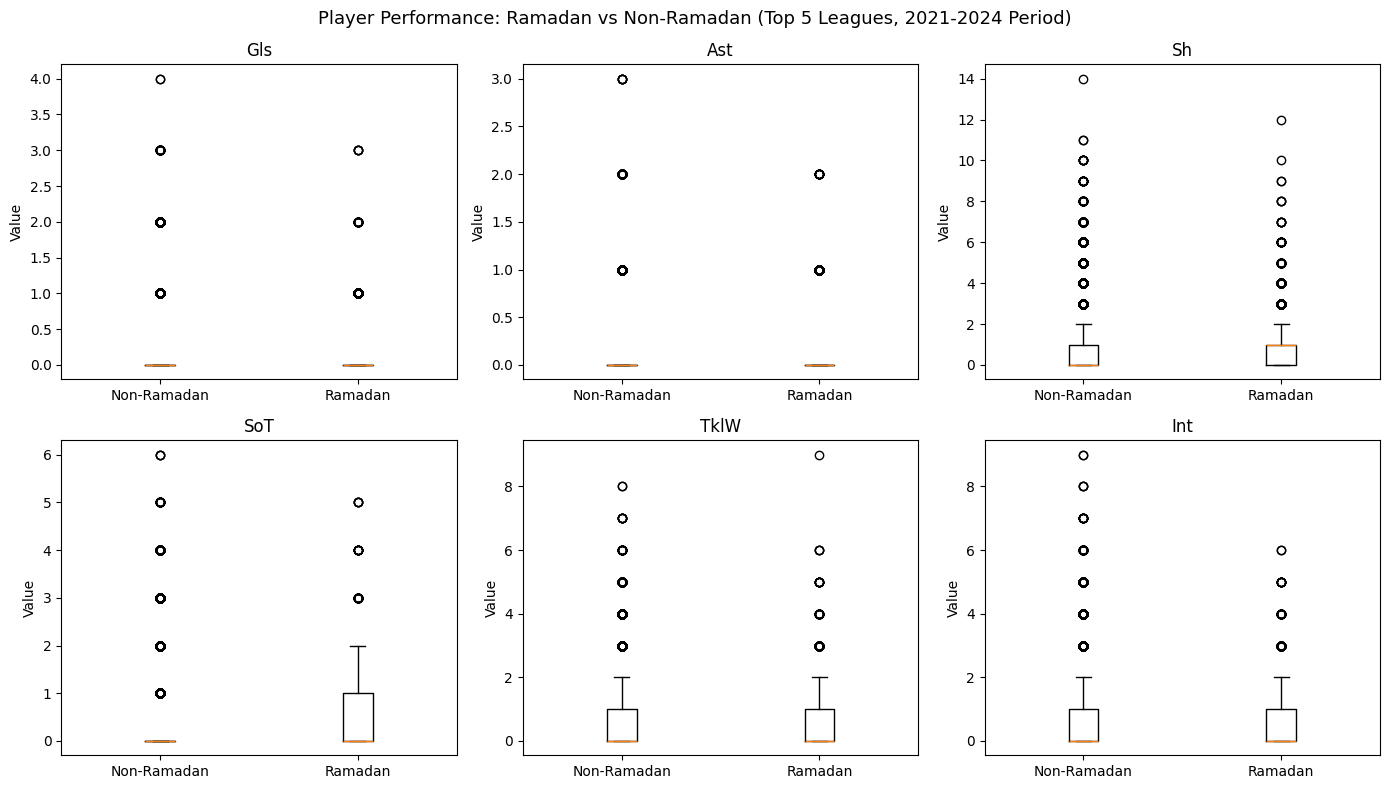

Plot saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ramadan_vals = df[df['is_ramadan']][metric].dropna()
    non_ramadan_vals = df[~df['is_ramadan']][metric].dropna()
    
    axes[i].boxplot([non_ramadan_vals, ramadan_vals], labels=['Non-Ramadan', 'Ramadan'])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Value')

plt.suptitle('Player Performance: Ramadan vs Non-Ramadan (Top 5 Leagues, 2021-2024 Period)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150)
plt.show()
print("Plot saved.")

                  Gls    Ast     Sh    SoT
ramadan_third                             
First (1-10)    0.107  0.045  0.879  0.300
Second (11-20)  0.133  0.063  0.964  0.381
Final (21-30)   0.108  0.070  1.007  0.361


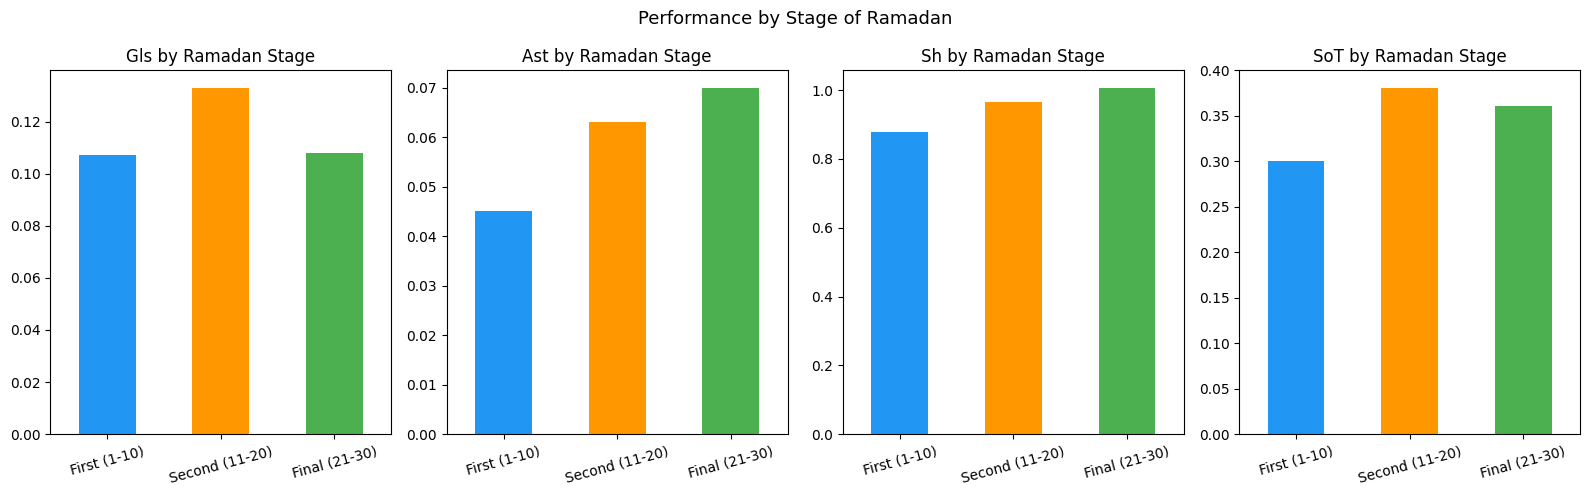

In [8]:
#Performance By Stage of Ramadan (H2)
ramadan_df = df[df['is_ramadan']].copy()
ramadan_df['ramadan_third'] = pd.cut(ramadan_df['days_into_ramadan'],
                                      bins=[0, 10, 20, 30],
                                      labels=['First (1-10)', 'Second (11-20)', 'Final (21-30)'])

third_comparison = ramadan_df.groupby('ramadan_third', observed=True)[['Gls', 'Ast', 'Sh', 'SoT']].mean().round(3)
print(third_comparison)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, metric in enumerate(['Gls', 'Ast', 'Sh', 'SoT']):
    third_comparison[metric].plot(kind='bar', ax=axes[i], color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[i].set_title(f'{metric} by Ramadan Stage')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Performance by Stage of Ramadan', fontsize=13)
plt.tight_layout()
plt.savefig('eda_ramadan_thirds.png', dpi=150)
plt.show()

In [9]:
#Mapping the Positions to Group (H3)
def map_position(pos):
    if pd.isna(pos) or str(pos) == '0':
        return None
    pos = str(pos)
    if any(x in pos for x in ['FW', 'RW', 'LW', 'ST', 'CF']):
        return 'Forward/Winger'
    elif any(x in pos for x in ['CM', 'DM', 'AM', 'RM', 'LM', 'MF']):
        return 'Midfielder'
    elif any(x in pos for x in ['CB', 'RB', 'LB', 'WB', 'DF']):
        return 'Defender'
    elif 'GK' in pos:
        return 'Goalkeeper'
    return None

df['position_group'] = df['pos'].apply(map_position)

print("H3 - Goals by position during Ramadan vs Non-Ramadan:")
for pos in ['Forward/Winger', 'Midfielder', 'Defender']:
    r = df[(df['is_ramadan']) & (df['position_group'] == pos)]['Gls']
    nr = df[(~df['is_ramadan']) & (df['position_group'] == pos)]['Gls']
    if len(r) > 0 and len(nr) > 0:
        diff = ((r.mean() - nr.mean()) / nr.mean() * 100) if nr.mean() > 0 else 0
        print(f"{pos}: Ramadan={r.mean():.4f}, Non-Ramadan={nr.mean():.4f}, Diff={diff:.1f}%")

H3 - Goals by position during Ramadan vs Non-Ramadan:
Forward/Winger: Ramadan=0.2226, Non-Ramadan=0.1991, Diff=11.8%
Midfielder: Ramadan=0.0901, Non-Ramadan=0.0801, Diff=12.5%
Defender: Ramadan=0.0253, Non-Ramadan=0.0357, Diff=-29.0%


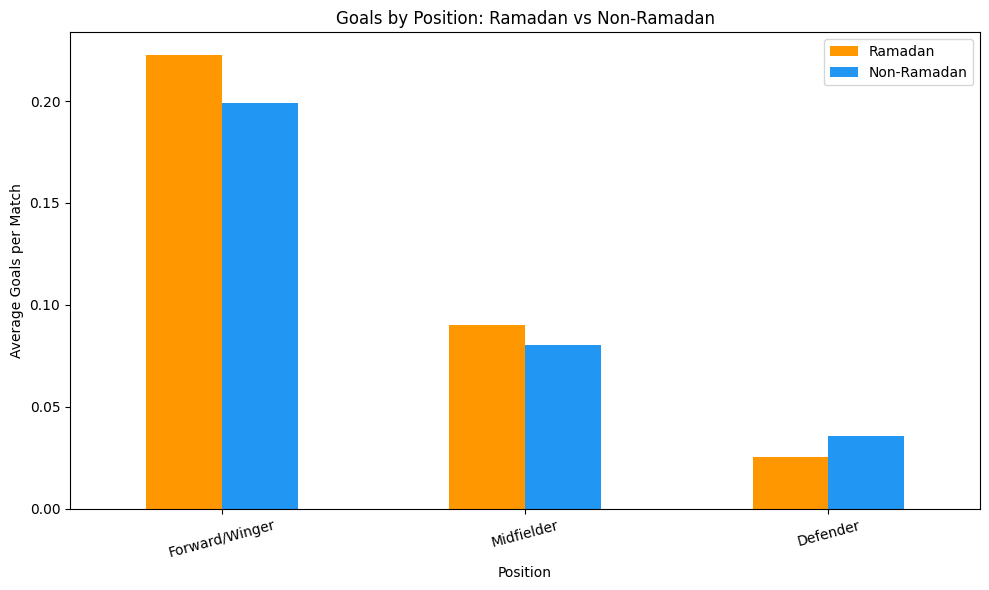

In [10]:
pos_data = []
for pos in ['Forward/Winger', 'Midfielder', 'Defender']:
    r = df[(df['is_ramadan']) & (df['position_group'] == pos)]['Gls'].mean()
    nr = df[(~df['is_ramadan']) & (df['position_group'] == pos)]['Gls'].mean()
    pos_data.append({'Position': pos, 'Ramadan': r, 'Non-Ramadan': nr})

pos_df = pd.DataFrame(pos_data).set_index('Position')

pos_df.plot(kind='bar', figsize=(10, 6), color=['#FF9800', '#2196F3'])
plt.title('Goals by Position: Ramadan vs Non-Ramadan')
plt.ylabel('Average Goals per Match')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('h3_position_goals.png', dpi=150)
plt.show()

## 4. Hypothesis Testing

In [11]:
#H1: Do Muslim Players Perform Significantly Better During Ramadan?
#Test On Goals With Two-Sample t-test

ramadan_gls = df[df['is_ramadan']]['Gls'].dropna()
non_ramadan_gls = df[~df['is_ramadan']]['Gls'].dropna()

t_stat, p_value = stats.ttest_ind(ramadan_gls, non_ramadan_gls, equal_var=False)

print("H1 - Goals: Ramadan vs Non-Ramadan")
print(f"Ramadan mean: {ramadan_gls.mean():.4f}")
print(f"Non-Ramadan mean: {non_ramadan_gls.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Reject H0 — significant difference found")
else:
    print("Result: Fail to reject H0 — no significant difference")

H1 - Goals: Ramadan vs Non-Ramadan
Ramadan mean: 0.1164
Non-Ramadan mean: 0.1046
T-statistic: 1.7210
P-value: 0.0853
Result: Fail to reject H0 — no significant difference


In [12]:
#H1 -> Shots and Shots on Target
for metric in ['Sh', 'SoT']:
    r = df[df['is_ramadan']][metric].dropna()
    nr = df[~df['is_ramadan']][metric].dropna()
    t_stat, p_value = stats.ttest_ind(r, nr, equal_var=False)
    print(f"H1 - {metric}: Ramadan mean={r.mean():.4f}, Non-Ramadan mean={nr.mean():.4f}")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Result: Reject H0 — significant difference found")
    else:
        print(f"Result: Fail to reject H0 — no significant difference")
    print()

H1 - Sh: Ramadan mean=0.9512, Non-Ramadan mean=0.9189
T-statistic: 1.2968, P-value: 0.1948
Result: Fail to reject H0 — no significant difference

H1 - SoT: Ramadan mean=0.3486, Non-Ramadan mean=0.3276
T-statistic: 1.6072, P-value: 0.1081
Result: Fail to reject H0 — no significant difference



In [13]:
#H2: Does Performance Improve As Ramadan Progresses?
ramadan_df = df[df['is_ramadan']].copy()
ramadan_df['ramadan_third'] = pd.cut(ramadan_df['days_into_ramadan'],
                                      bins=[0, 10, 20, 30],
                                      labels=['First', 'Second', 'Final'])

first = ramadan_df[ramadan_df['ramadan_third'] == 'First']['Gls'].dropna()
second = ramadan_df[ramadan_df['ramadan_third'] == 'Second']['Gls'].dropna()
final = ramadan_df[ramadan_df['ramadan_third'] == 'Final']['Gls'].dropna()

t_stat_1, p_value_1 = stats.ttest_ind(final, first, equal_var=False)
t_stat_2, p_value_2 = stats.ttest_ind(second, first, equal_var=False)

print("H2 - Goals by Ramadan stage:")
print(f"First third mean: {first.mean():.4f}")
print(f"Second third mean: {second.mean():.4f}")
print(f"Final third mean: {final.mean():.4f}")
print()
print(f"Final vs First: T-stat={t_stat_1:.4f}, P-value={p_value_1:.4f}")
if p_value_1 < 0.05:
    print("Result: Reject H0 — significant improvement in final third")
else:
    print("Result: Fail to reject H0 — no significant difference")
print()
print(f"Second vs First: T-stat={t_stat_2:.4f}, P-value={p_value_2:.4f}")
if p_value_2 < 0.05:
    print("Result: Reject H0 — significant improvement in second third")
else:
    print("Result: Fail to reject H0 — no significant difference")

H2 - Goals by Ramadan stage:
First third mean: 0.1072
Second third mean: 0.1331
Final third mean: 0.1081

Final vs First: T-stat=0.0548, P-value=0.9563
Result: Fail to reject H0 — no significant difference

Second vs First: T-stat=1.5683, P-value=0.1170
Result: Fail to reject H0 — no significant difference


In [14]:
#H3: Do Attacking Players Show Stronger Improvement During Ramadan?
print("H3 - Goals by position: Ramadan vs Non-Ramadan")
print()
for pos in ['Forward/Winger', 'Midfielder', 'Defender']:
    r = df[(df['is_ramadan']) & (df['position_group'] == pos)]['Gls'].dropna()
    nr = df[(~df['is_ramadan']) & (df['position_group'] == pos)]['Gls'].dropna()
    t_stat, p_value = stats.ttest_ind(r, nr, equal_var=False)
    diff = ((r.mean() - nr.mean()) / nr.mean() * 100) if nr.mean() > 0 else 0
    print(f"{pos}:")
    print(f"  Ramadan mean={r.mean():.4f}, Non-Ramadan mean={nr.mean():.4f}, Diff={diff:.1f}%")
    print(f"  T-stat={t_stat:.4f}, P-value={p_value:.4f}")
    if p_value < 0.05:
        print(f"  Result: Reject H0 — significant difference found")
    else:
        print(f"  Result: Fail to reject H0 — no significant difference")
    print()

H3 - Goals by position: Ramadan vs Non-Ramadan

Forward/Winger:
  Ramadan mean=0.2226, Non-Ramadan mean=0.1991, Diff=11.8%
  T-stat=1.4237, P-value=0.1548
  Result: Fail to reject H0 — no significant difference

Midfielder:
  Ramadan mean=0.0901, Non-Ramadan mean=0.0801, Diff=12.5%
  T-stat=1.1233, P-value=0.2615
  Result: Fail to reject H0 — no significant difference

Defender:
  Ramadan mean=0.0253, Non-Ramadan mean=0.0357, Diff=-29.0%
  T-stat=-1.5965, P-value=0.1107
  Result: Fail to reject H0 — no significant difference



In [15]:
#Summary Of Hypothesis Testing Results

print("SUMMARY OF HYPOTHESIS TESTING")


print("""
H1 — Do Muslim players perform better during Ramadan?
  Goals: +10.5%  (p = 0.085) —> the trend is present, but not significant
  Shots: +3.5%  (p = 0.195) —> not significant
  Shots on Target: +6.4%  (p = 0.108) —> the trend is present, but not significant

H2 — Does performance improve as Ramadan progresses?
  Goals: First third = 0.107 | Second third = 0.133 | Final third = 0.108
  Final vs First:  p = 0.956 —> not significant
  Second vs First: p = 0.117 —> not significant

H3 — Do attacking players show a stronger Ramadan effect?
  Forwards: +11.8%  (p = 0.155) —> not significant
  Midfielders: +12.5%  (p = 0.262) —> not significant
  Defenders: -29.0%  (p = 0.111) —> not significant

Overall:
  All three hypotheses show consistent trends in the expected direction for attacking metrics, but none reach statistical significance (p < 0.05).
  The results suggest a need for more precise Muslim player identification or a larger dataset for analyzation.
""")

SUMMARY OF HYPOTHESIS TESTING

H1 — Do Muslim players perform better during Ramadan?
  Goals: +10.5%  (p = 0.085) —> the trend is present, but not significant
  Shots: +3.5%  (p = 0.195) —> not significant
  Shots on Target: +6.4%  (p = 0.108) —> the trend is present, but not significant

H2 — Does performance improve as Ramadan progresses?
  Goals: First third = 0.107 | Second third = 0.133 | Final third = 0.108
  Final vs First:  p = 0.956 —> not significant
  Second vs First: p = 0.117 —> not significant

H3 — Do attacking players show a stronger Ramadan effect?
  Forwards: +11.8%  (p = 0.155) —> not significant
  Midfielders: +12.5%  (p = 0.262) —> not significant
  Defenders: -29.0%  (p = 0.111) —> not significant

Overall:
  All three hypotheses show consistent trends in the expected direction for attacking metrics, but none reach statistical significance (p < 0.05).
  The results suggest a need for more precise Muslim player identification or a larger dataset for analyzation.



## 5. Machine Learning

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create binary target: did the player score?
df['scored'] = (df['Gls'] > 0).astype(int)

# Encode categorical features
le_pos = LabelEncoder()
le_league = LabelEncoder()

ml_df = df[['scored', 'is_ramadan', 'days_into_ramadan', 'pos', 'league']].dropna().copy()
ml_df['pos_encoded'] = le_pos.fit_transform(ml_df['pos'])
ml_df['league_encoded'] = le_league.fit_transform(ml_df['league'])
ml_df['is_ramadan_int'] = ml_df['is_ramadan'].astype(int)

# Features and target
X = ml_df[['is_ramadan_int', 'days_into_ramadan', 'pos_encoded', 'league_encoded']]
y = ml_df['scored']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Scoring rate: {y.mean():.3f} (share of matches where player scored)")

Training set size: 25943
Test set size: 6486
Scoring rate: 0.093 (share of matches where player scored)


In [18]:
# Logistic Regression with class balancing
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("LOGISTIC REGRESSION (balanced)")
print("=" * 40)
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(log_reg, X, y, cv=kf, scoring='f1')
print(f"\n5-Fold CV F1 Score: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

LOGISTIC REGRESSION (balanced)
              precision    recall  f1-score   support

           0       0.92      0.50      0.65      5932
           1       0.09      0.56      0.16       554

    accuracy                           0.50      6486
   macro avg       0.51      0.53      0.40      6486
weighted avg       0.85      0.50      0.60      6486

Confusion Matrix:
[[2948 2984]
 [ 245  309]]

5-Fold CV F1 Score: 0.1519 (+/- 0.0094)


In [19]:
# Random Forest with class balancing
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST (balanced)")
print("=" * 40)
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

cv_scores_rf = cross_val_score(rf, X, y, cv=kf, scoring='f1')
print(f"\n5-Fold CV F1 Score: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Feature importance
print("\nFeature Importance:")
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

RANDOM FOREST (balanced)
              precision    recall  f1-score   support

           0       0.96      0.74      0.83      5932
           1       0.19      0.66      0.30       554

    accuracy                           0.73      6486
   macro avg       0.58      0.70      0.57      6486
weighted avg       0.89      0.73      0.79      6486

Confusion Matrix:
[[4379 1553]
 [ 187  367]]

5-Fold CV F1 Score: 0.3036 (+/- 0.0063)

Feature Importance:
  is_ramadan_int: 0.0085
  days_into_ramadan: 0.1426
  pos_encoded: 0.7873
  league_encoded: 0.0616


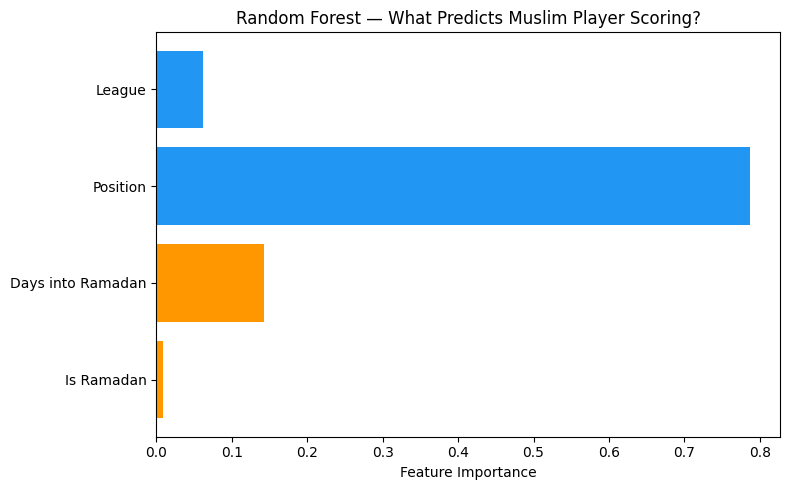

In [20]:
features = ['Is Ramadan', 'Days into Ramadan', 'Position', 'League']
importances = rf.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importances, color=['#FF9800' if i < 2 else '#2196F3' for i in range(len(features))])
plt.xlabel('Feature Importance')
plt.title('Random Forest — What Predicts Muslim Player Scoring?')
plt.tight_layout()
plt.savefig('ml_feature_importance.png', dpi=150)
plt.show()

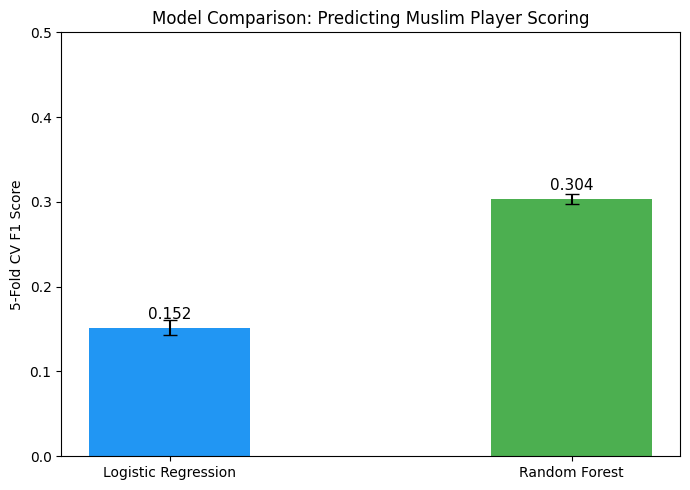

In [21]:
# Model comparison
models = ['Logistic Regression', 'Random Forest']
f1_scores = [cv_scores_lr.mean(), cv_scores_rf.mean()]
stds = [cv_scores_lr.std(), cv_scores_rf.std()]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, f1_scores, color=['#2196F3', '#4CAF50'], width=0.4)
plt.errorbar(models, f1_scores, yerr=stds, fmt='none', color='black', capsize=5)
plt.ylabel('5-Fold CV F1 Score')
plt.title('Model Comparison: Predicting Muslim Player Scoring')
plt.ylim(0, 0.5)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('ml_model_comparison.png', dpi=150)
plt.show()